In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


data_path = Path(
    "../data/raw/eia_tx_residential_price.csv"
)

df = pd.read_csv(
    data_path,
    parse_dates=["period"],
)

df.head()

,period,stateid,stateDescription,sectorid,sectorName,price,price-units
0,2015-01-01,TX,Texas,RES,residential,11.49,cents per kilowatt-hour
1,2015-02-01,TX,Texas,RES,residential,11.62,cents per kilowatt-hour
2,2015-03-01,TX,Texas,RES,residential,11.56,cents per kilowatt-hour
3,2015-04-01,TX,Texas,RES,residential,12.10,cents per kilowatt-hour
4,2015-05-01,TX,Texas,RES,residential,12.04,cents per kilowatt-hour


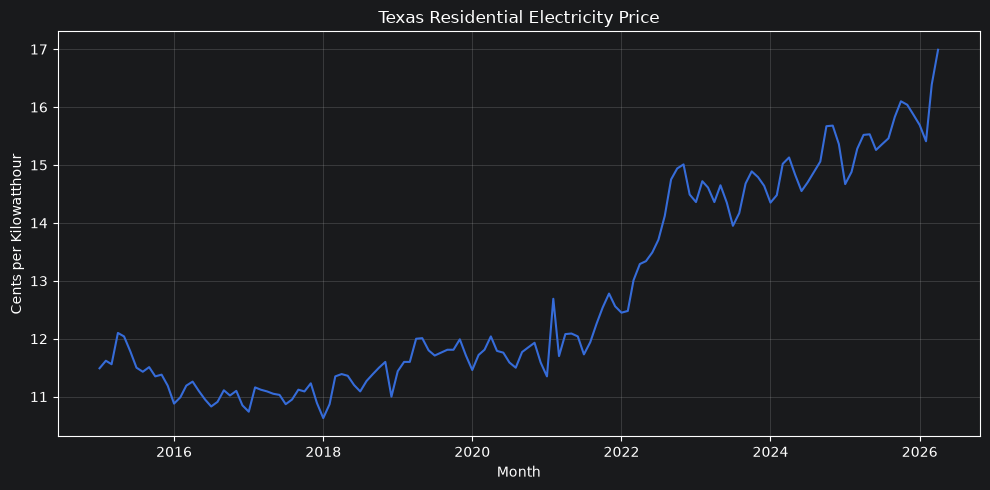

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    df["period"],
    df["price"],
)

ax.set_title(
    "Texas Residential Electricity Price"
)
ax.set_xlabel("Month")
ax.set_ylabel(
    "Cents per Kilowatthour"
)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
print(df.info())

print("\nDate range:")
print(df["period"].min(), "to", df["period"].max())

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate months:")
print(df.duplicated(subset=["period"]).sum())

print("\nPrice summary:")
print(df["price"].describe())

print("\nUnits:")
print(df["price-units"].unique())

<class 'pandas.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   period            136 non-null    datetime64[us]
 1   stateid           136 non-null    str           
 2   stateDescription  136 non-null    str           
 3   sectorid          136 non-null    str           
 4   sectorName        136 non-null    str           
 5   price             136 non-null    float64       
 6   price-units       136 non-null    str           
dtypes: datetime64[us](1), float64(1), str(5)
memory usage: 7.6 KB
None

Date range:
2015-01-01 00:00:00 to 2026-04-01 00:00:00

Missing values:
period              0
stateid             0
stateDescription    0
sectorid            0
sectorName          0
price               0
price-units         0
dtype: int64

Duplicate months:
0

Price summary:
count    136.000000
mean      12.758676
std        1.740293
min       10

In [16]:
expected_months = pd.date_range(
    start=df["period"].min(),
    end=df["period"].max(),
    freq="MS",
)

missing_months = expected_months.difference(df["period"])

print("Missing months:")
print(missing_months)

Missing months:
DatetimeIndex([], dtype='datetime64[us]', freq='MS')


In [17]:
assert df["stateid"].eq("TX").all()
assert df["sectorid"].eq("RES").all()
assert df["price"].gt(0).all()
assert df["period"].is_monotonic_increasing

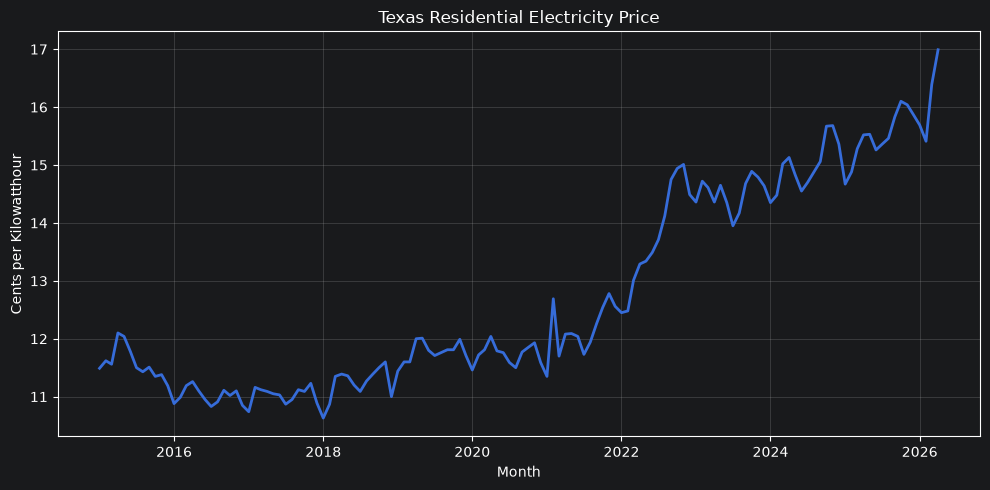

In [18]:
from pathlib import Path

figure_path = Path(
    "../reports/figures/tx_residential_electricity_price.png"
)

figure_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    df["period"],
    df["price"],
    linewidth=2,
)

ax.set_title(
    "Texas Residential Electricity Price"
)
ax.set_xlabel("Month")
ax.set_ylabel(
    "Cents per Kilowatthour"
)
ax.grid(alpha=0.3)

fig.tight_layout()

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()